In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 400
import seaborn as sns

In [4]:
df = pd.read_csv("realistic_synthetic_chat_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   conversation_id  500 non-null    int64 
 1   patient_message  500 non-null    object
 2   doctor_response  500 non-null    object
 3   intent           500 non-null    object
 4   sentiment        500 non-null    object
 5   summary          500 non-null    object
 6   key_points       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [6]:
df.columns

Index(['conversation_id', 'patient_message', 'doctor_response', 'intent',
       'sentiment', 'summary', 'key_points'],
      dtype='object')

In [8]:
df['intent'].value_counts()

intent
general_questions      97
request_appointment    95
discuss_symptoms       80
follow_up              77
complaint              76
ask_prescription       75
Name: count, dtype: int64

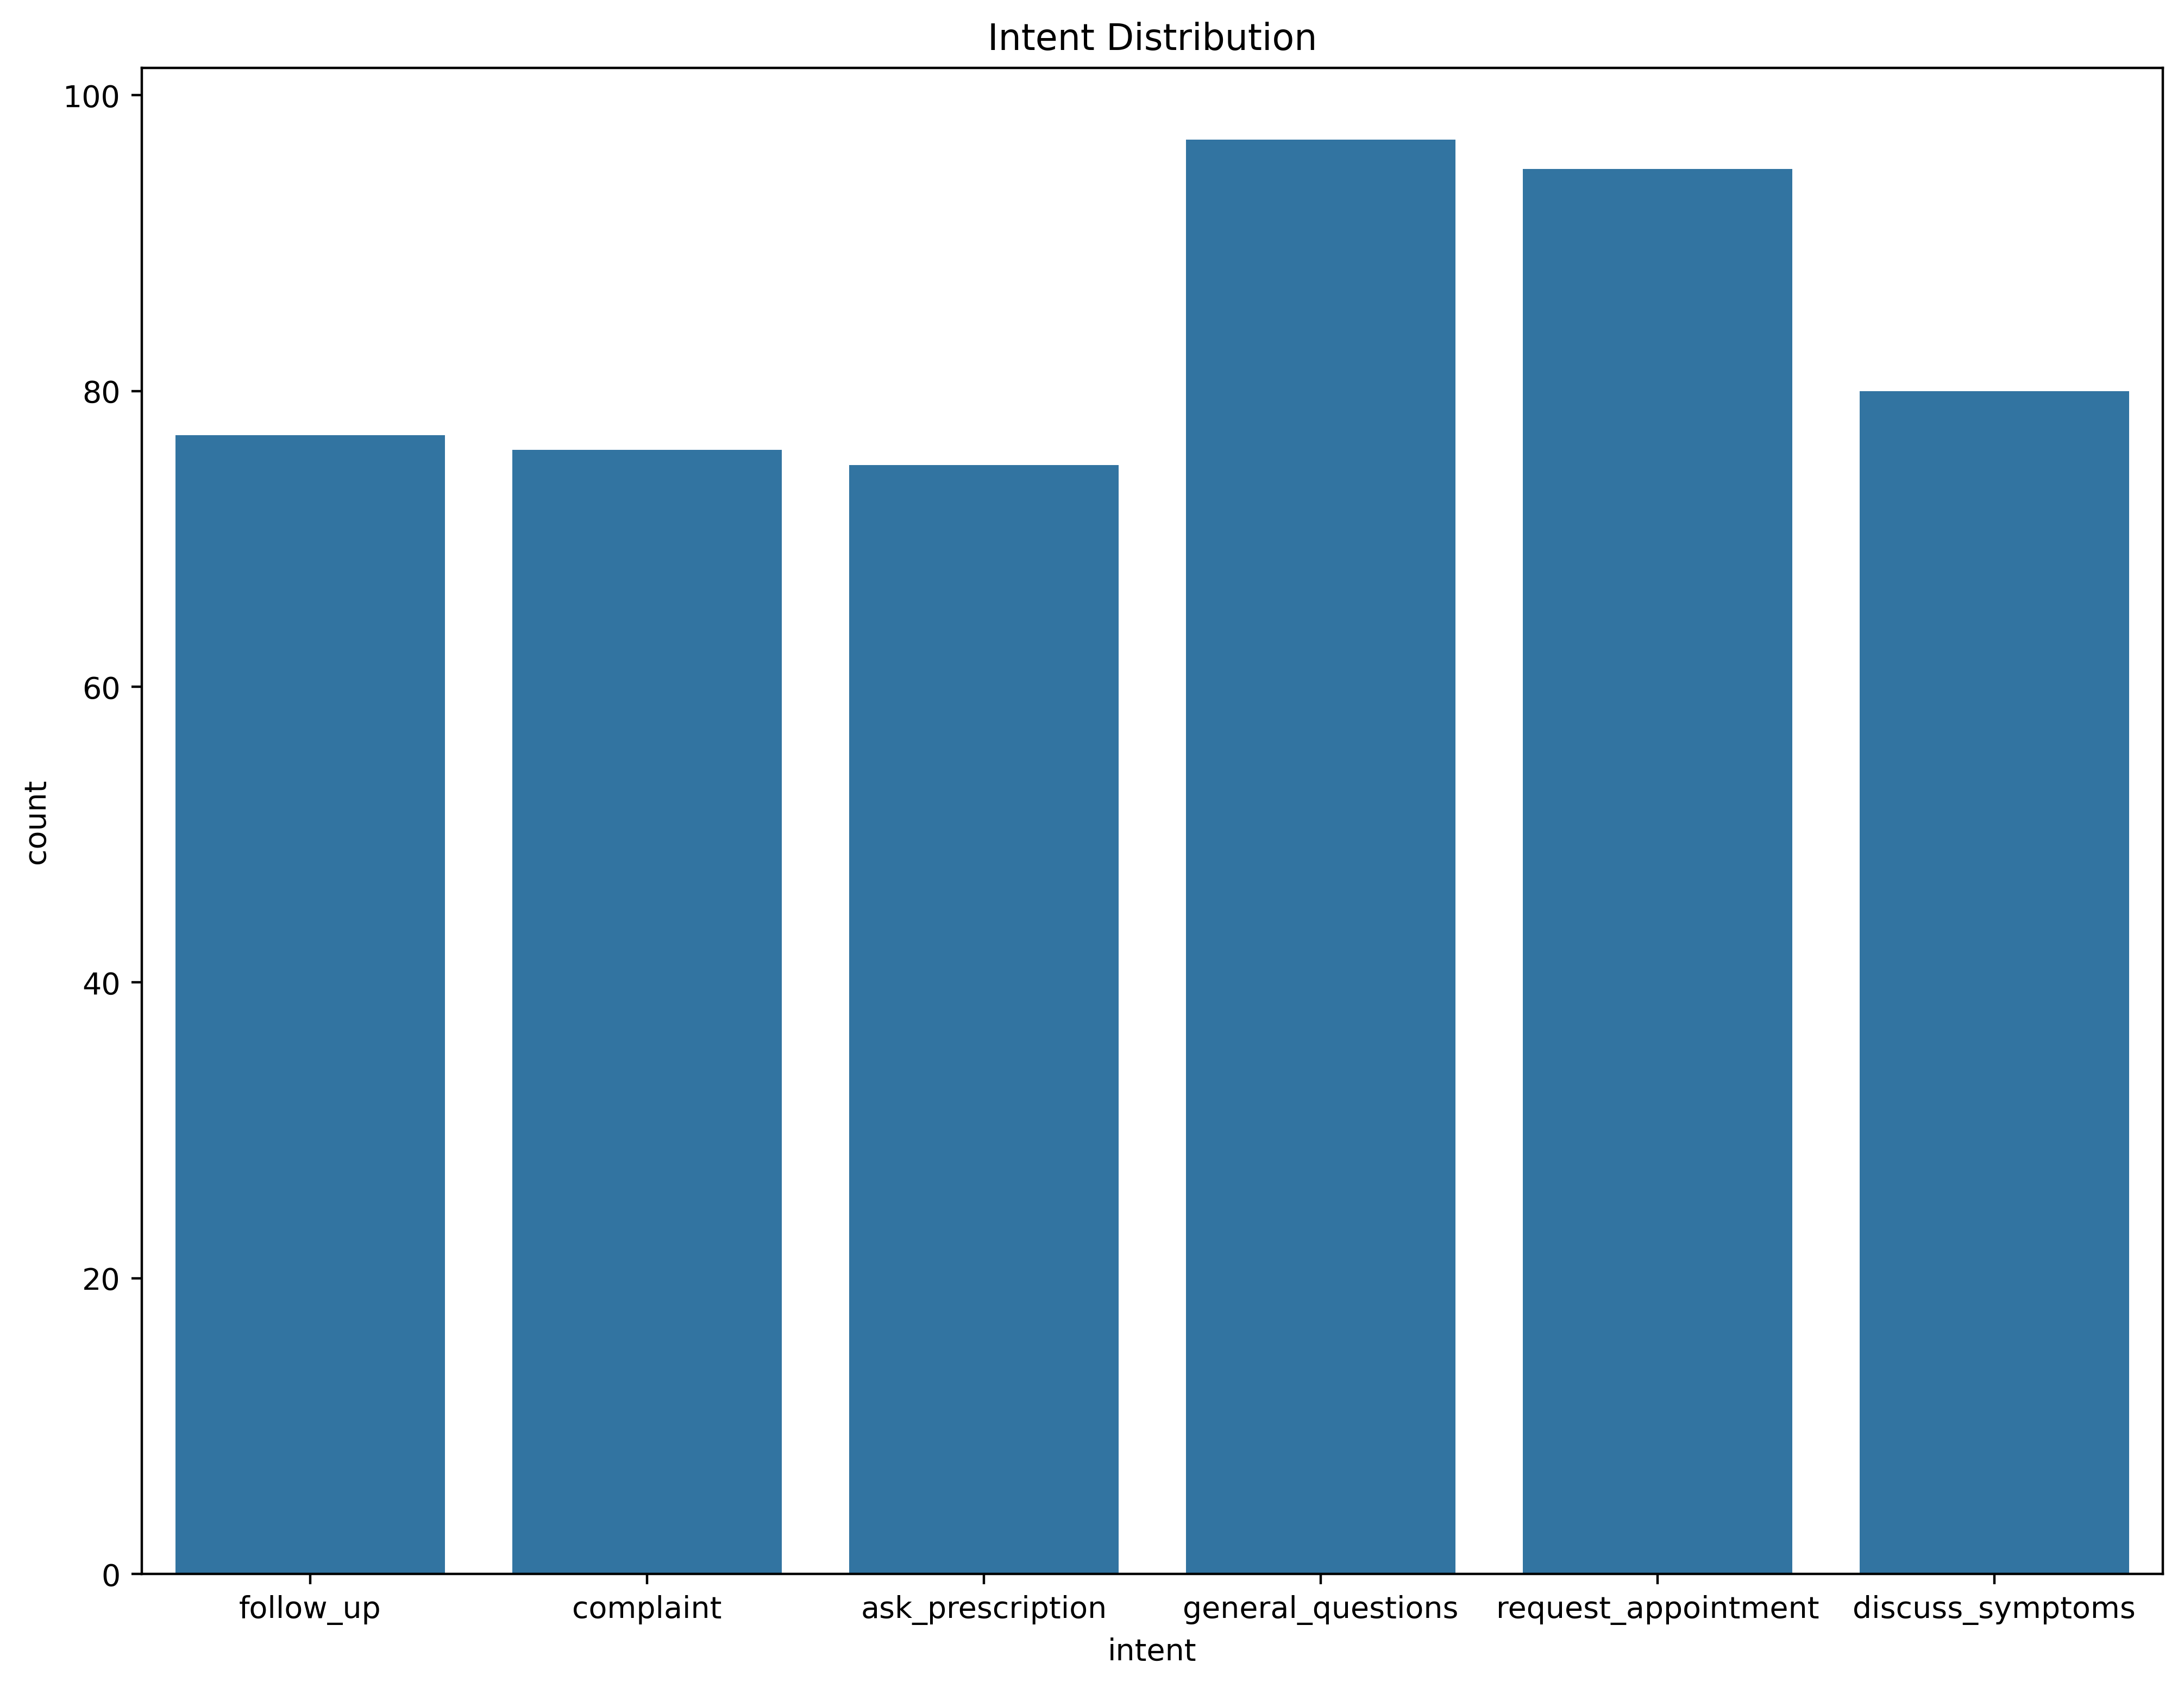

In [10]:
plt.figure(figsize = (12,9))
sns.countplot(data = df, x = "intent")
plt.title("Intent Distribution")
plt.xticks(rotation=0)
plt.show()

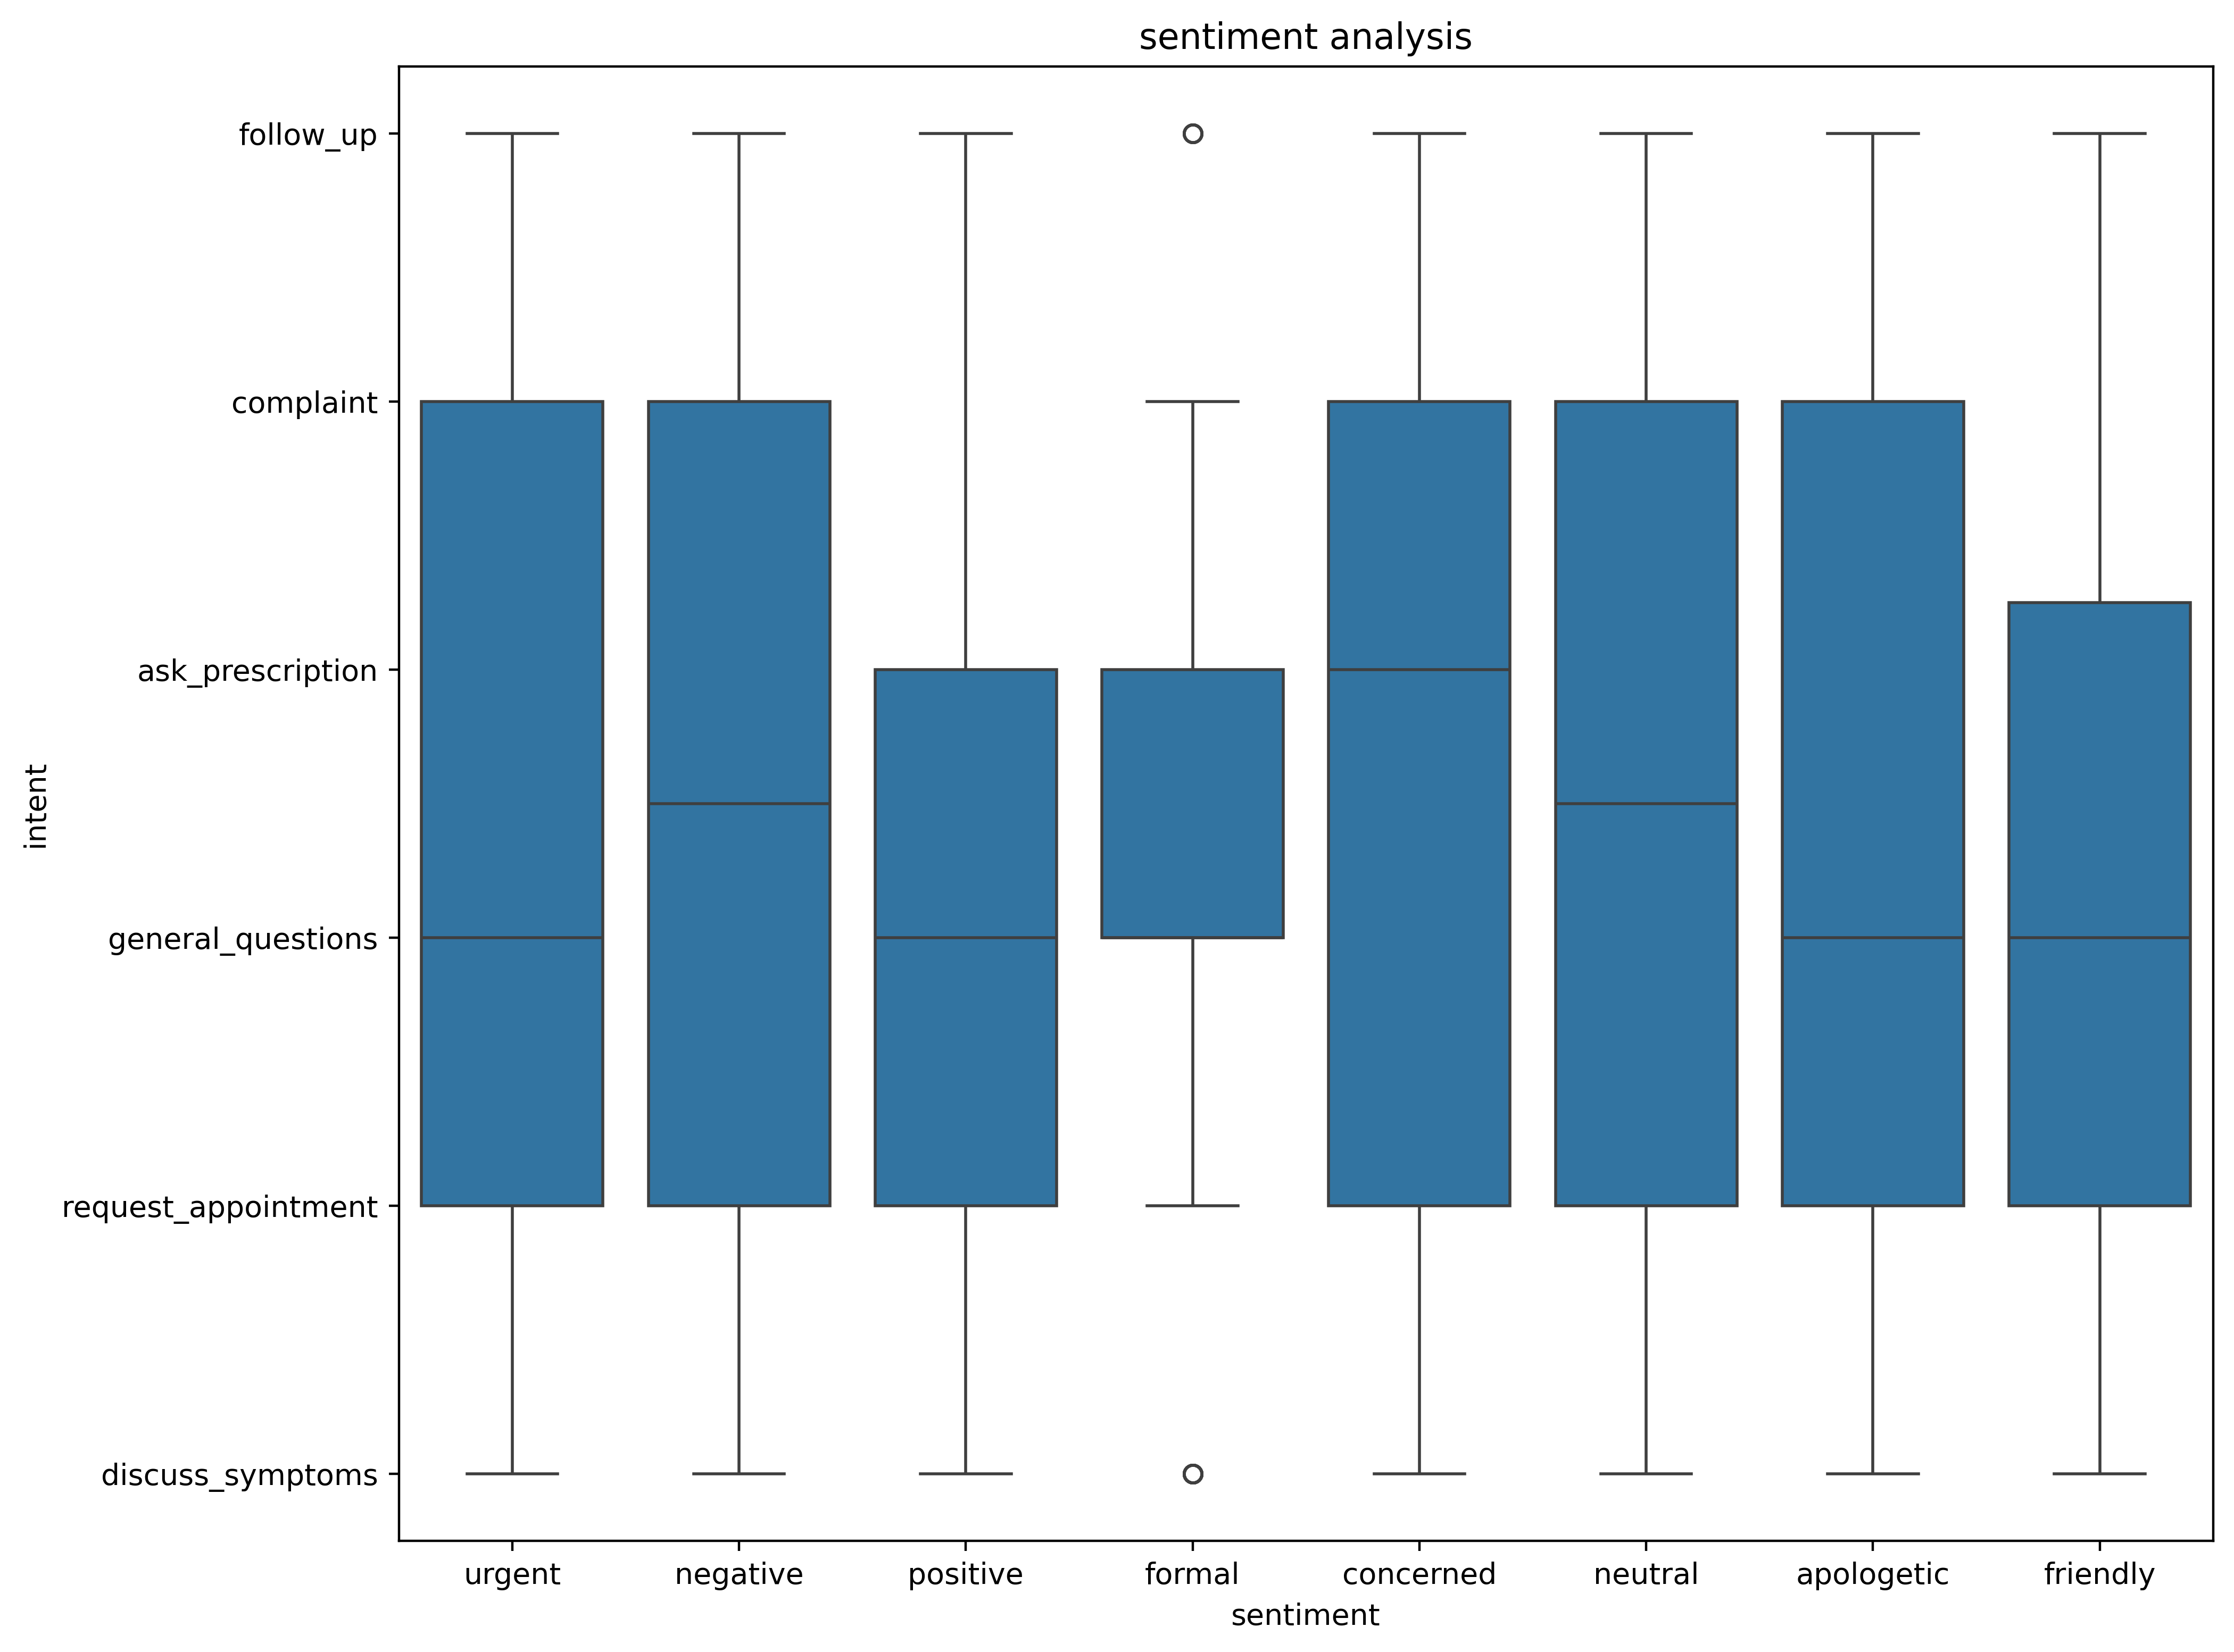

In [12]:
plt.figure(figsize=(11,9))
sns.boxplot(data = df, x = 'sentiment', y = "intent")
plt.title("sentiment analysis")
plt.show()

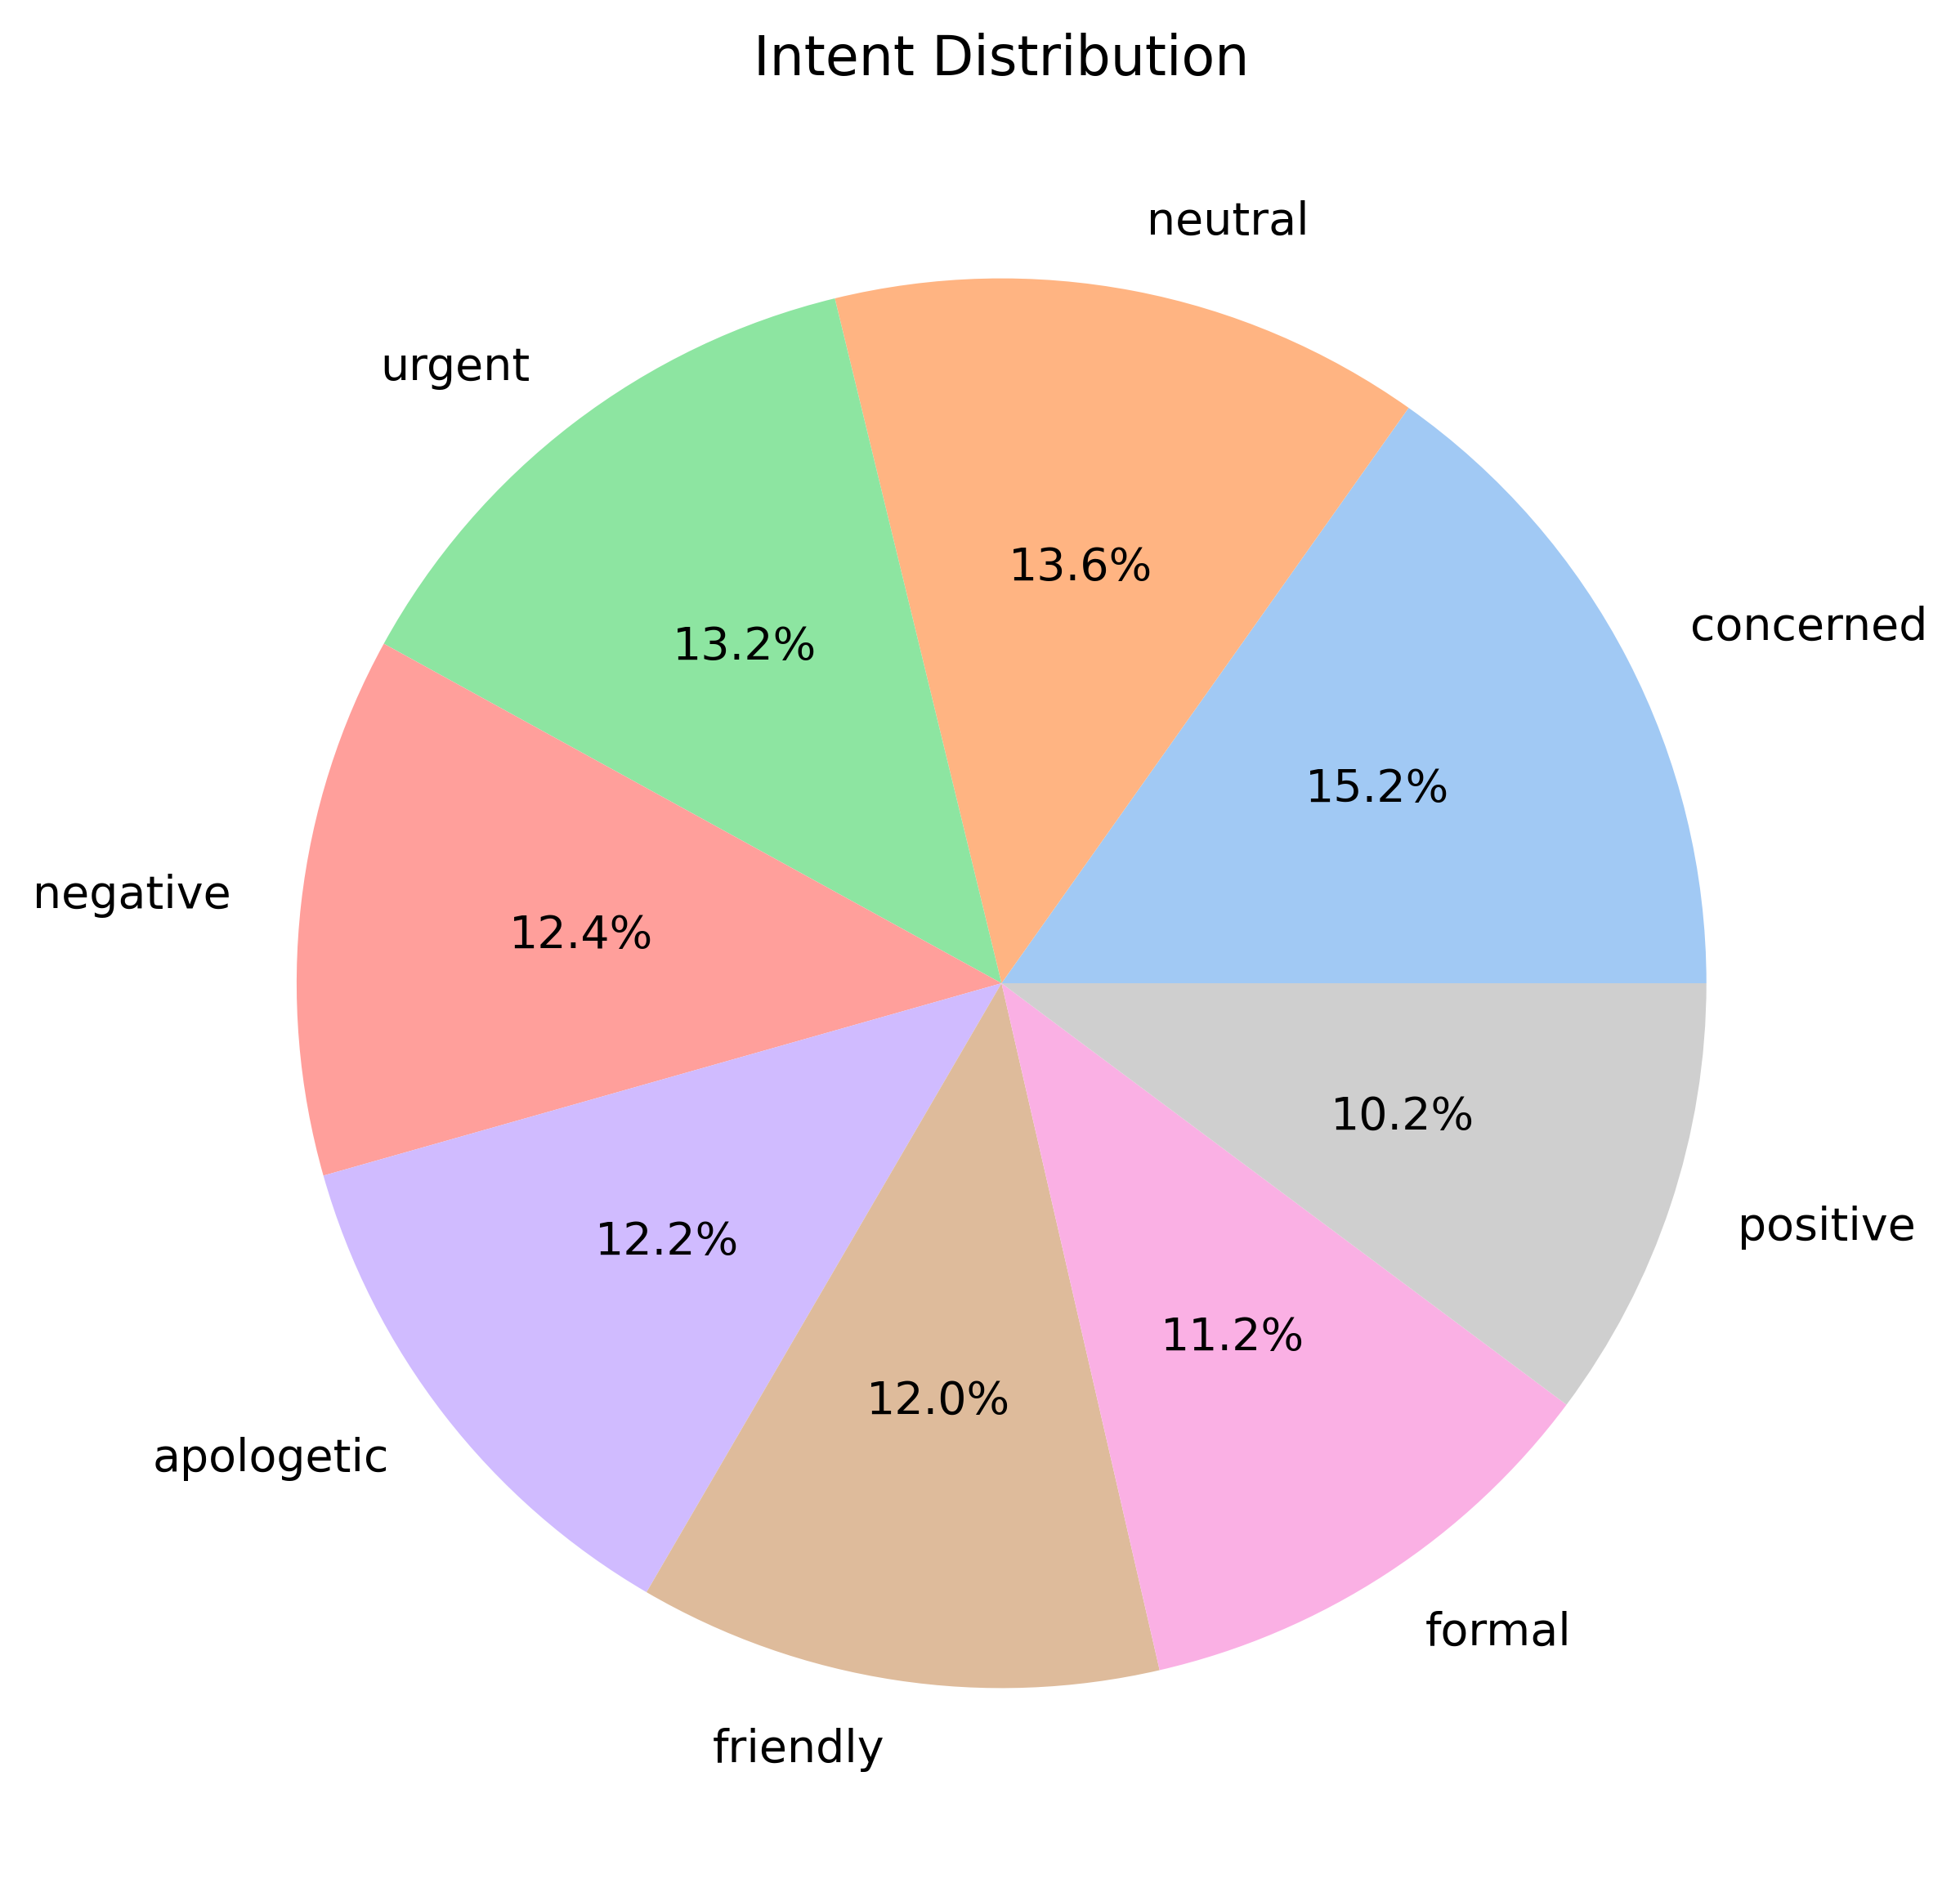

In [13]:
plt.figure(figsize = (11,7))
plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].value_counts().index, 
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel'))
plt.title('Intent Distribution')
plt.show()

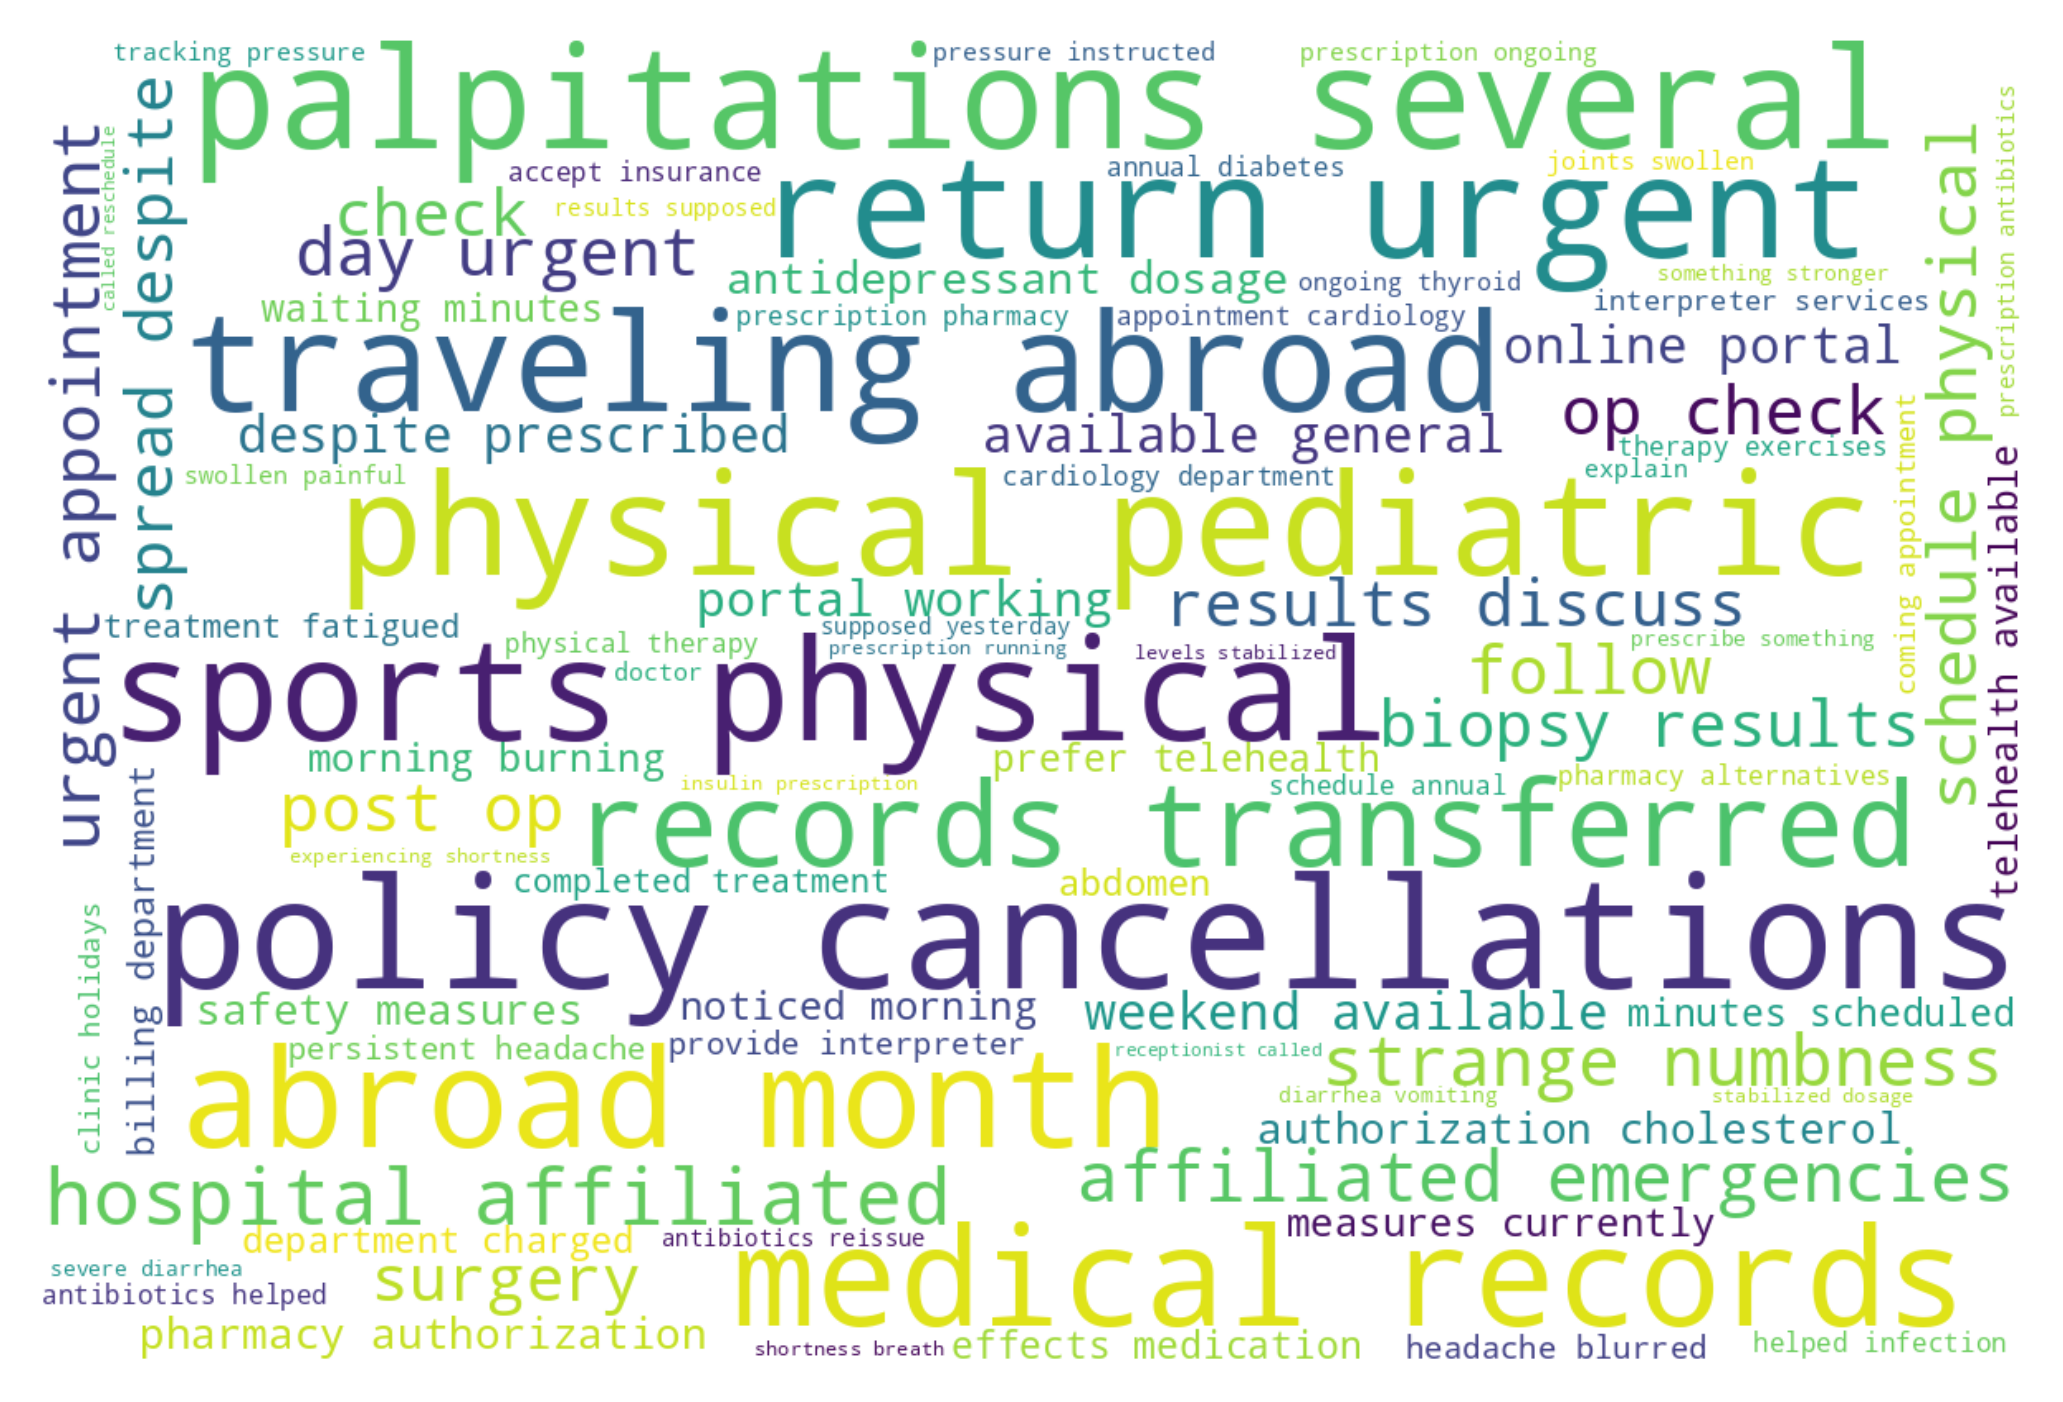

In [16]:
from wordcloud import WordCloud
key_points_text = ' '.join(df['key_points'].dropna().astype(str))
wordcloud = WordCloud(width = 1200, height = 800 , background_color = "white").generate(key_points_text)
plt.imshow(wordcloud,  interpolation='bilinear')
plt.axis('off')
plt.show()

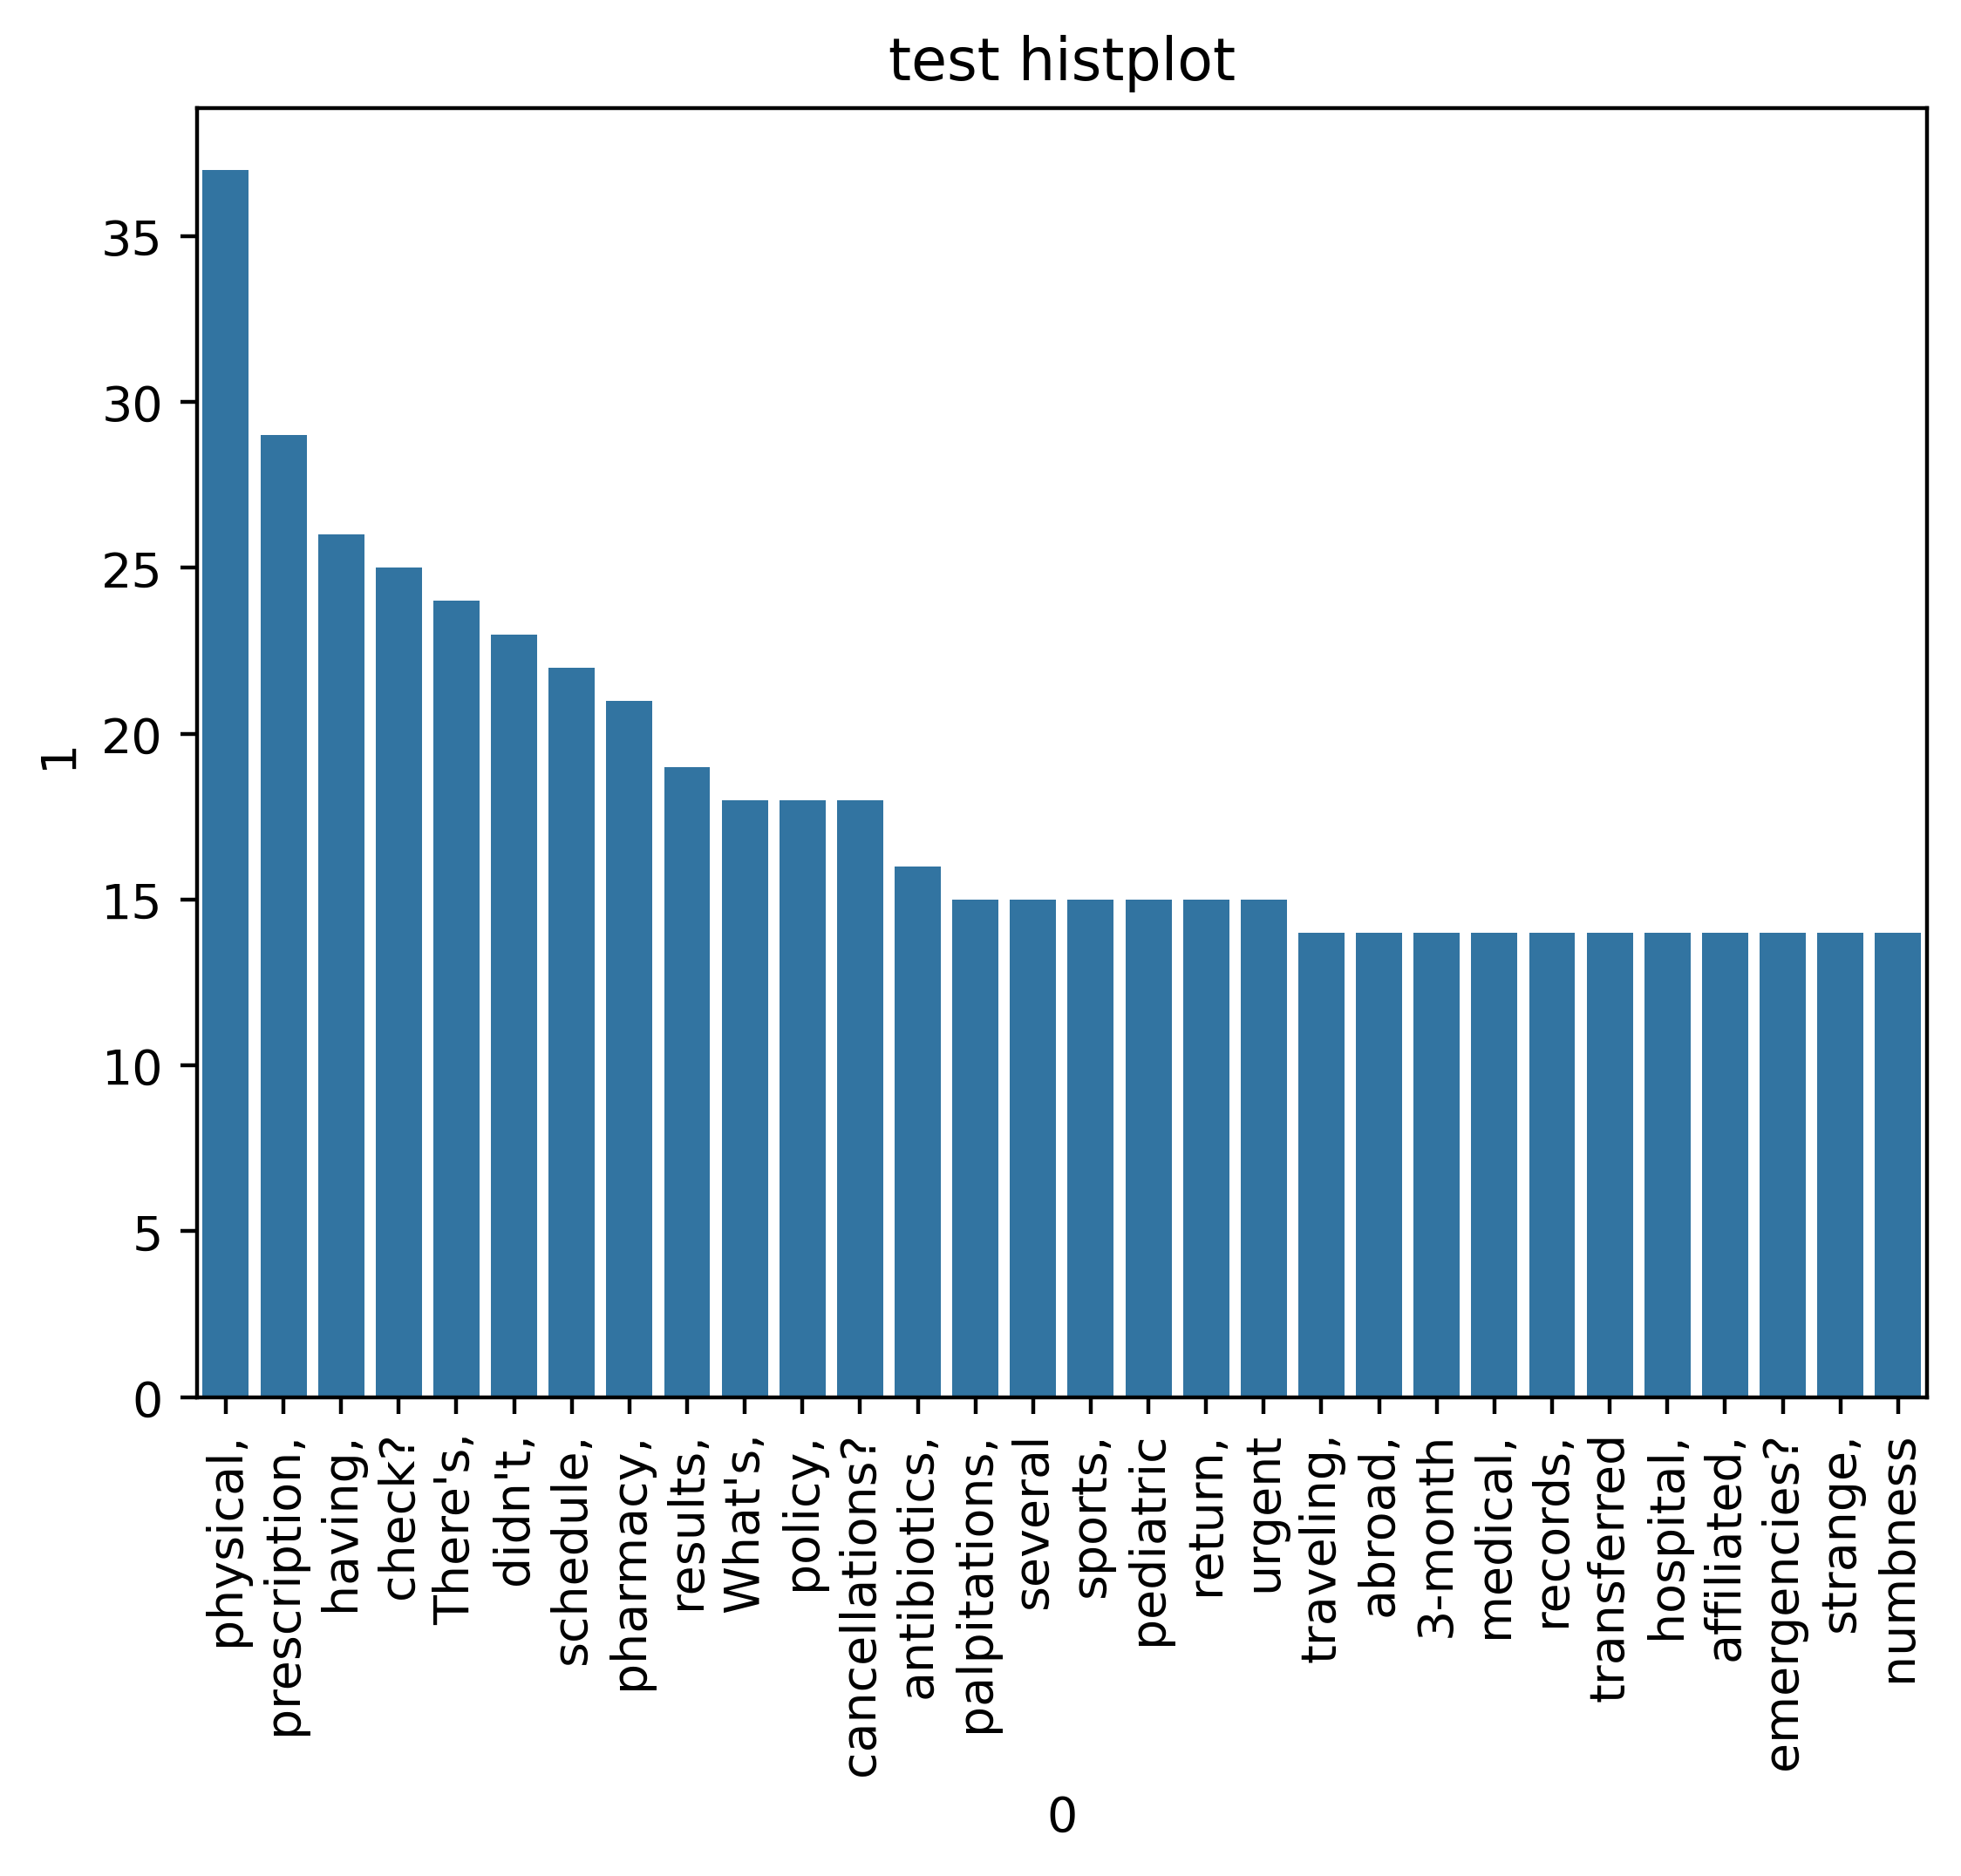

In [17]:
from collections import Counter
cunt_word = [ word  for i in df['key_points'].to_list()  for word in i.split()  ]
sns.barplot(x = pd.DataFrame(Counter(cunt_word).most_common(30))[0], y = pd.DataFrame(Counter(cunt_word).most_common(30))[1])
plt.title("test histplot")
plt.xticks(rotation = 'vertical')
plt.show()

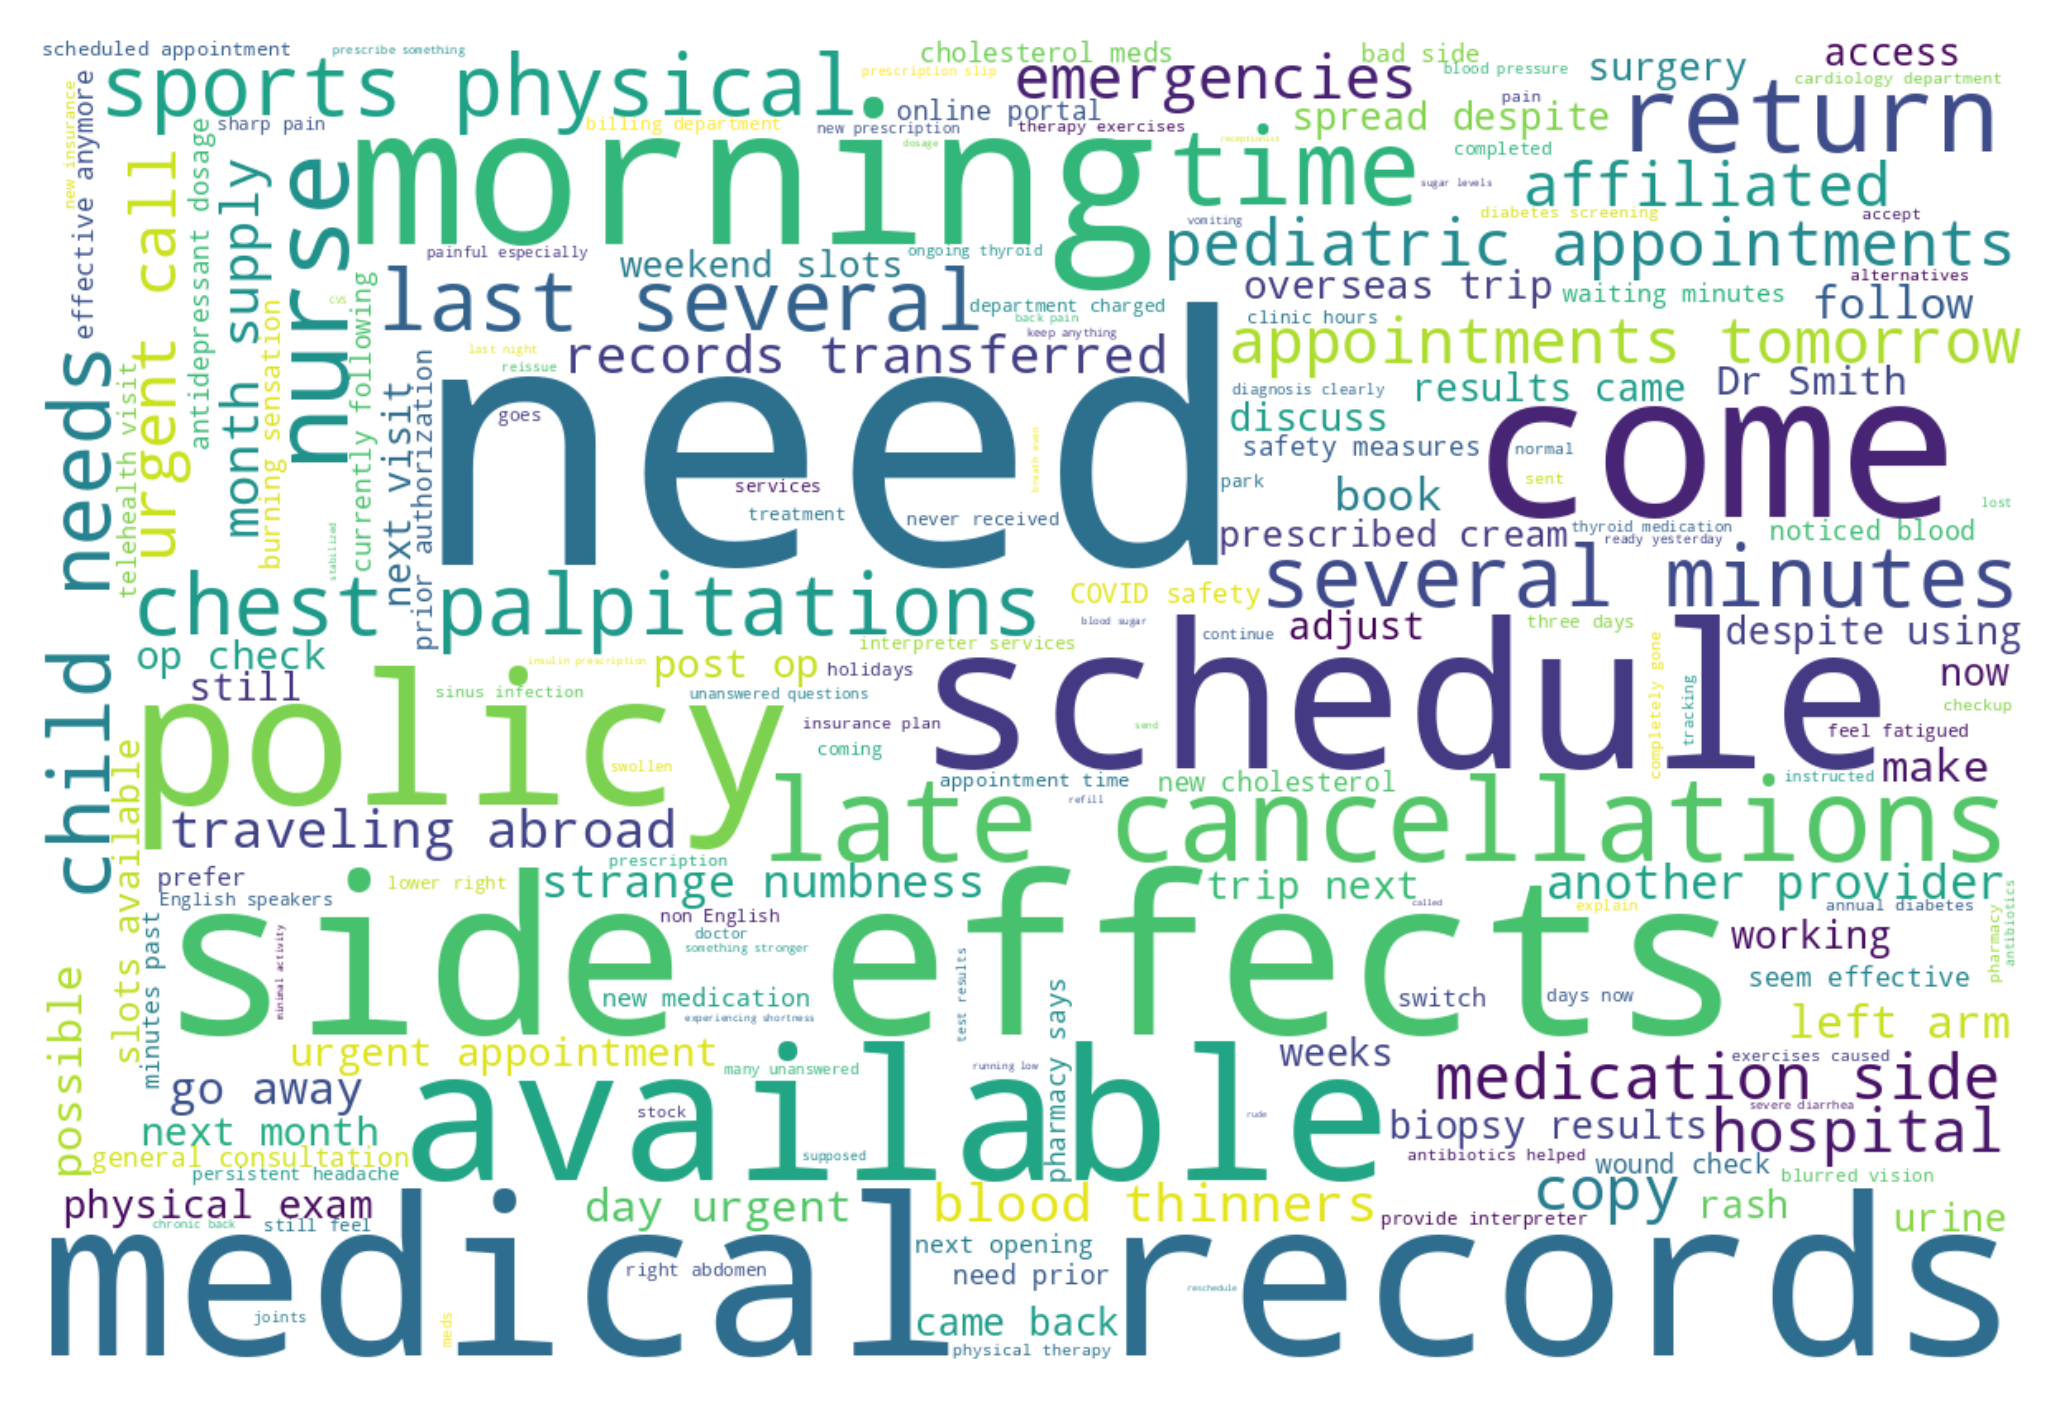

In [20]:
from wordcloud import WordCloud
patient_message = ' '.join(df['patient_message'].dropna().astype(str))
wordcloud = WordCloud(width = 1200, height = 800 , background_color = "white").generate(patient_message)
plt.imshow(wordcloud,  interpolation='bilinear')
plt.axis('off')
plt.show()

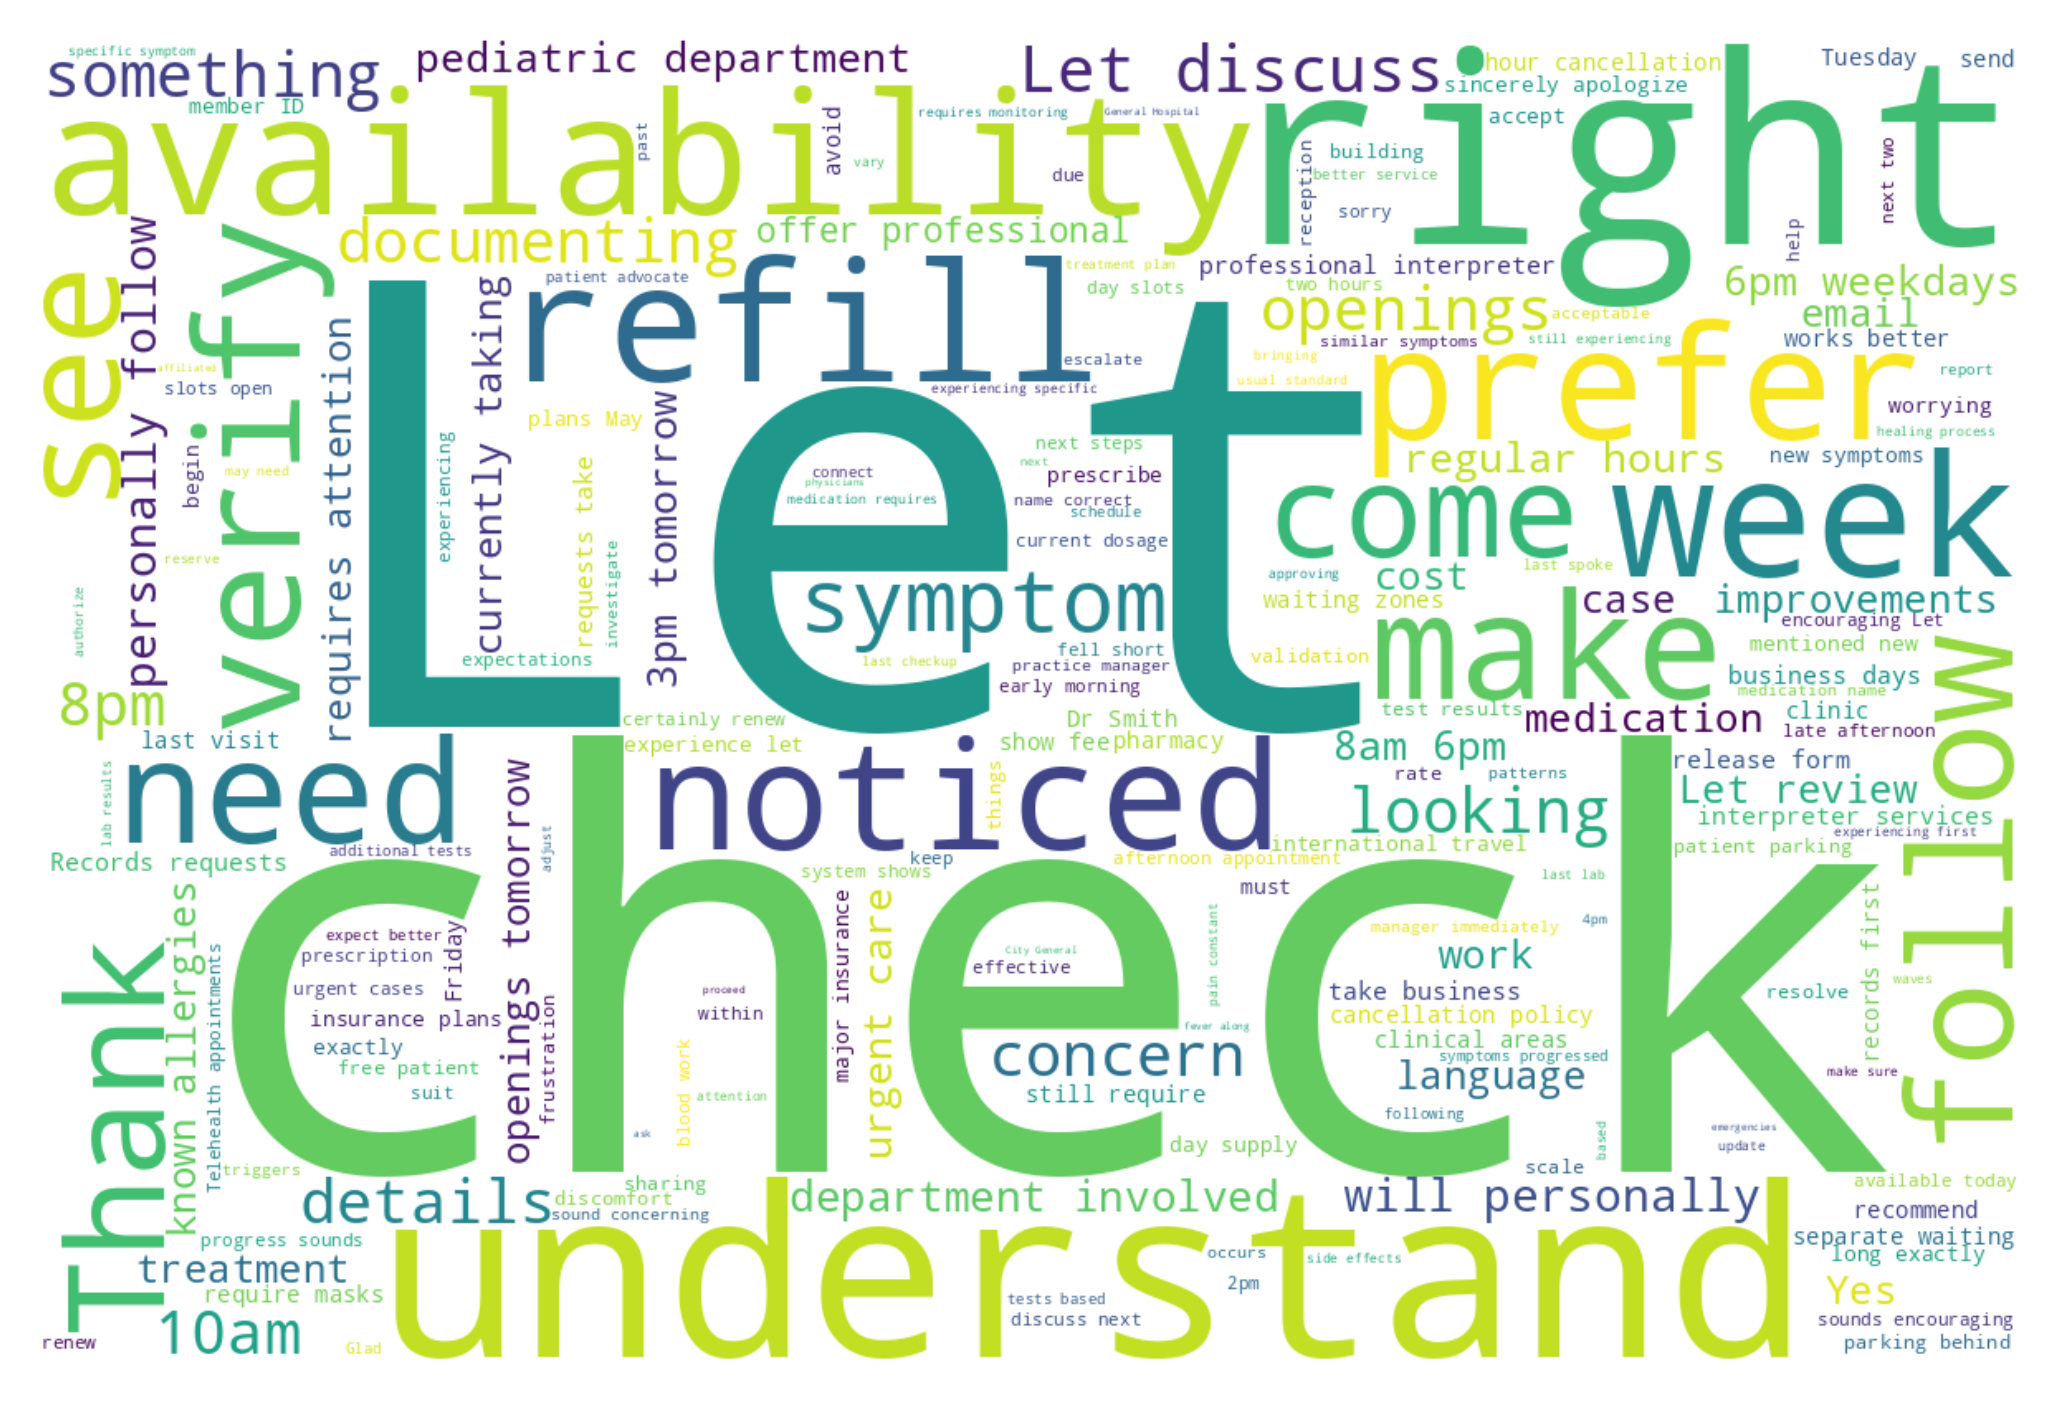

In [21]:
from wordcloud import WordCloud
doctor_response = ' '.join(df['doctor_response'].dropna().astype(str))
wordcloud = WordCloud(width = 1200, height = 800 , background_color = "white").generate(doctor_response)
plt.imshow(wordcloud,  interpolation='bilinear')
plt.axis('off')
plt.show()

In [22]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\arfit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arfit/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\arfit/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
import re 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [28]:
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import joblib 

C:\Users\arfit\anaconda3\envs\task_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
req_df = df[["patient_message","intent"]]
req_df.dropna()
req_df.head()

,patient_message,intent
0,The biopsy results came back - can we discuss ...,follow_up
1,The billing department charged me for services...,complaint
2,I completed the treatment but still feel fatig...,follow_up
3,I'm traveling abroad and need a 3-month supply...,ask_prescription
4,The rash has spread despite using the prescrib...,follow_up


In [30]:
le = LabelEncoder()
req_df['label'] = le.fit_transform(df['intent'])

C:\Users\arfit\AppData\Local\Temp\ipykernel_12816\1268869479.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  req_df['label'] = le.fit_transform(df['intent'])


In [31]:
req_df

,patient_message,intent,label
0,The biopsy results came back - can we discuss ...,follow_up,3
1,The billing department charged me for services...,complaint,1
2,I completed the treatment but still feel fatig...,follow_up,3
3,I'm traveling abroad and need a 3-month supply...,ask_prescription,0
4,The rash has spread despite using the prescrib...,follow_up,3
...,...,...,...
495,Which hospital are you affiliated with for eme...,general_questions,4
496,What's your policy on late cancellations?,general_questions,4
497,The nurse didn't return my urgent call about m...,complaint,1
498,I've been tracking my blood pressure as instru...,follow_up,3


In [32]:
joblib.dump(le,"intent_label_encoded.pkl")
req_df[['intent','label']].drop_duplicates().sort_values('label')

,intent,label
3,ask_prescription,0
1,complaint,1
12,discuss_symptoms,2
0,follow_up,3
5,general_questions,4
6,request_appointment,5


In [33]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenis(text):
    return tokenizer(text['patient_message'], truncation = True, padding = "max_length")

In [34]:
dataset = Dataset.from_pandas(req_df[['patient_message', 'label']])
dataset = dataset.train_test_split(test_size=0.2)
dataset = dataset.map(tokenis, batched=True)

Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 2056.47 examples/s]


In [42]:
num_labels = req_df['label'].nunique()
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
training_args = TrainingArguments(
    output_dir="C:/works/task_agenixai/intent_model",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
)


In [46]:
#  Define Metrics
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average="weighted")
    }


In [29]:
# 🚀 8. Train the Model
trainer_model = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    compute_metrics=compute_metrics
)

trainer_model.train()

Step,Training Loss


TrainOutput(global_step=150, training_loss=0.4040687815348307, metrics={'train_runtime': 1522.7793, 'train_samples_per_second': 0.788, 'train_steps_per_second': 0.099, 'total_flos': 315744605798400.0, 'train_loss': 0.4040687815348307, 'epoch': 3.0})

In [30]:
# Evaluate
trainer_model.evaluate()

# Optional: Classification Report
preds_output = trainer_model.predict(dataset['test'])
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))


                     precision    recall  f1-score   support

   ask_prescription       1.00      1.00      1.00        10
          complaint       1.00      1.00      1.00        21
   discuss_symptoms       1.00      1.00      1.00        16
          follow_up       1.00      1.00      1.00        15
  general_questions       1.00      1.00      1.00        19
request_appointment       1.00      1.00      1.00        19

           accuracy                           1.00       100
          macro avg       1.00      1.00      1.00       100
       weighted avg       1.00      1.00      1.00       100



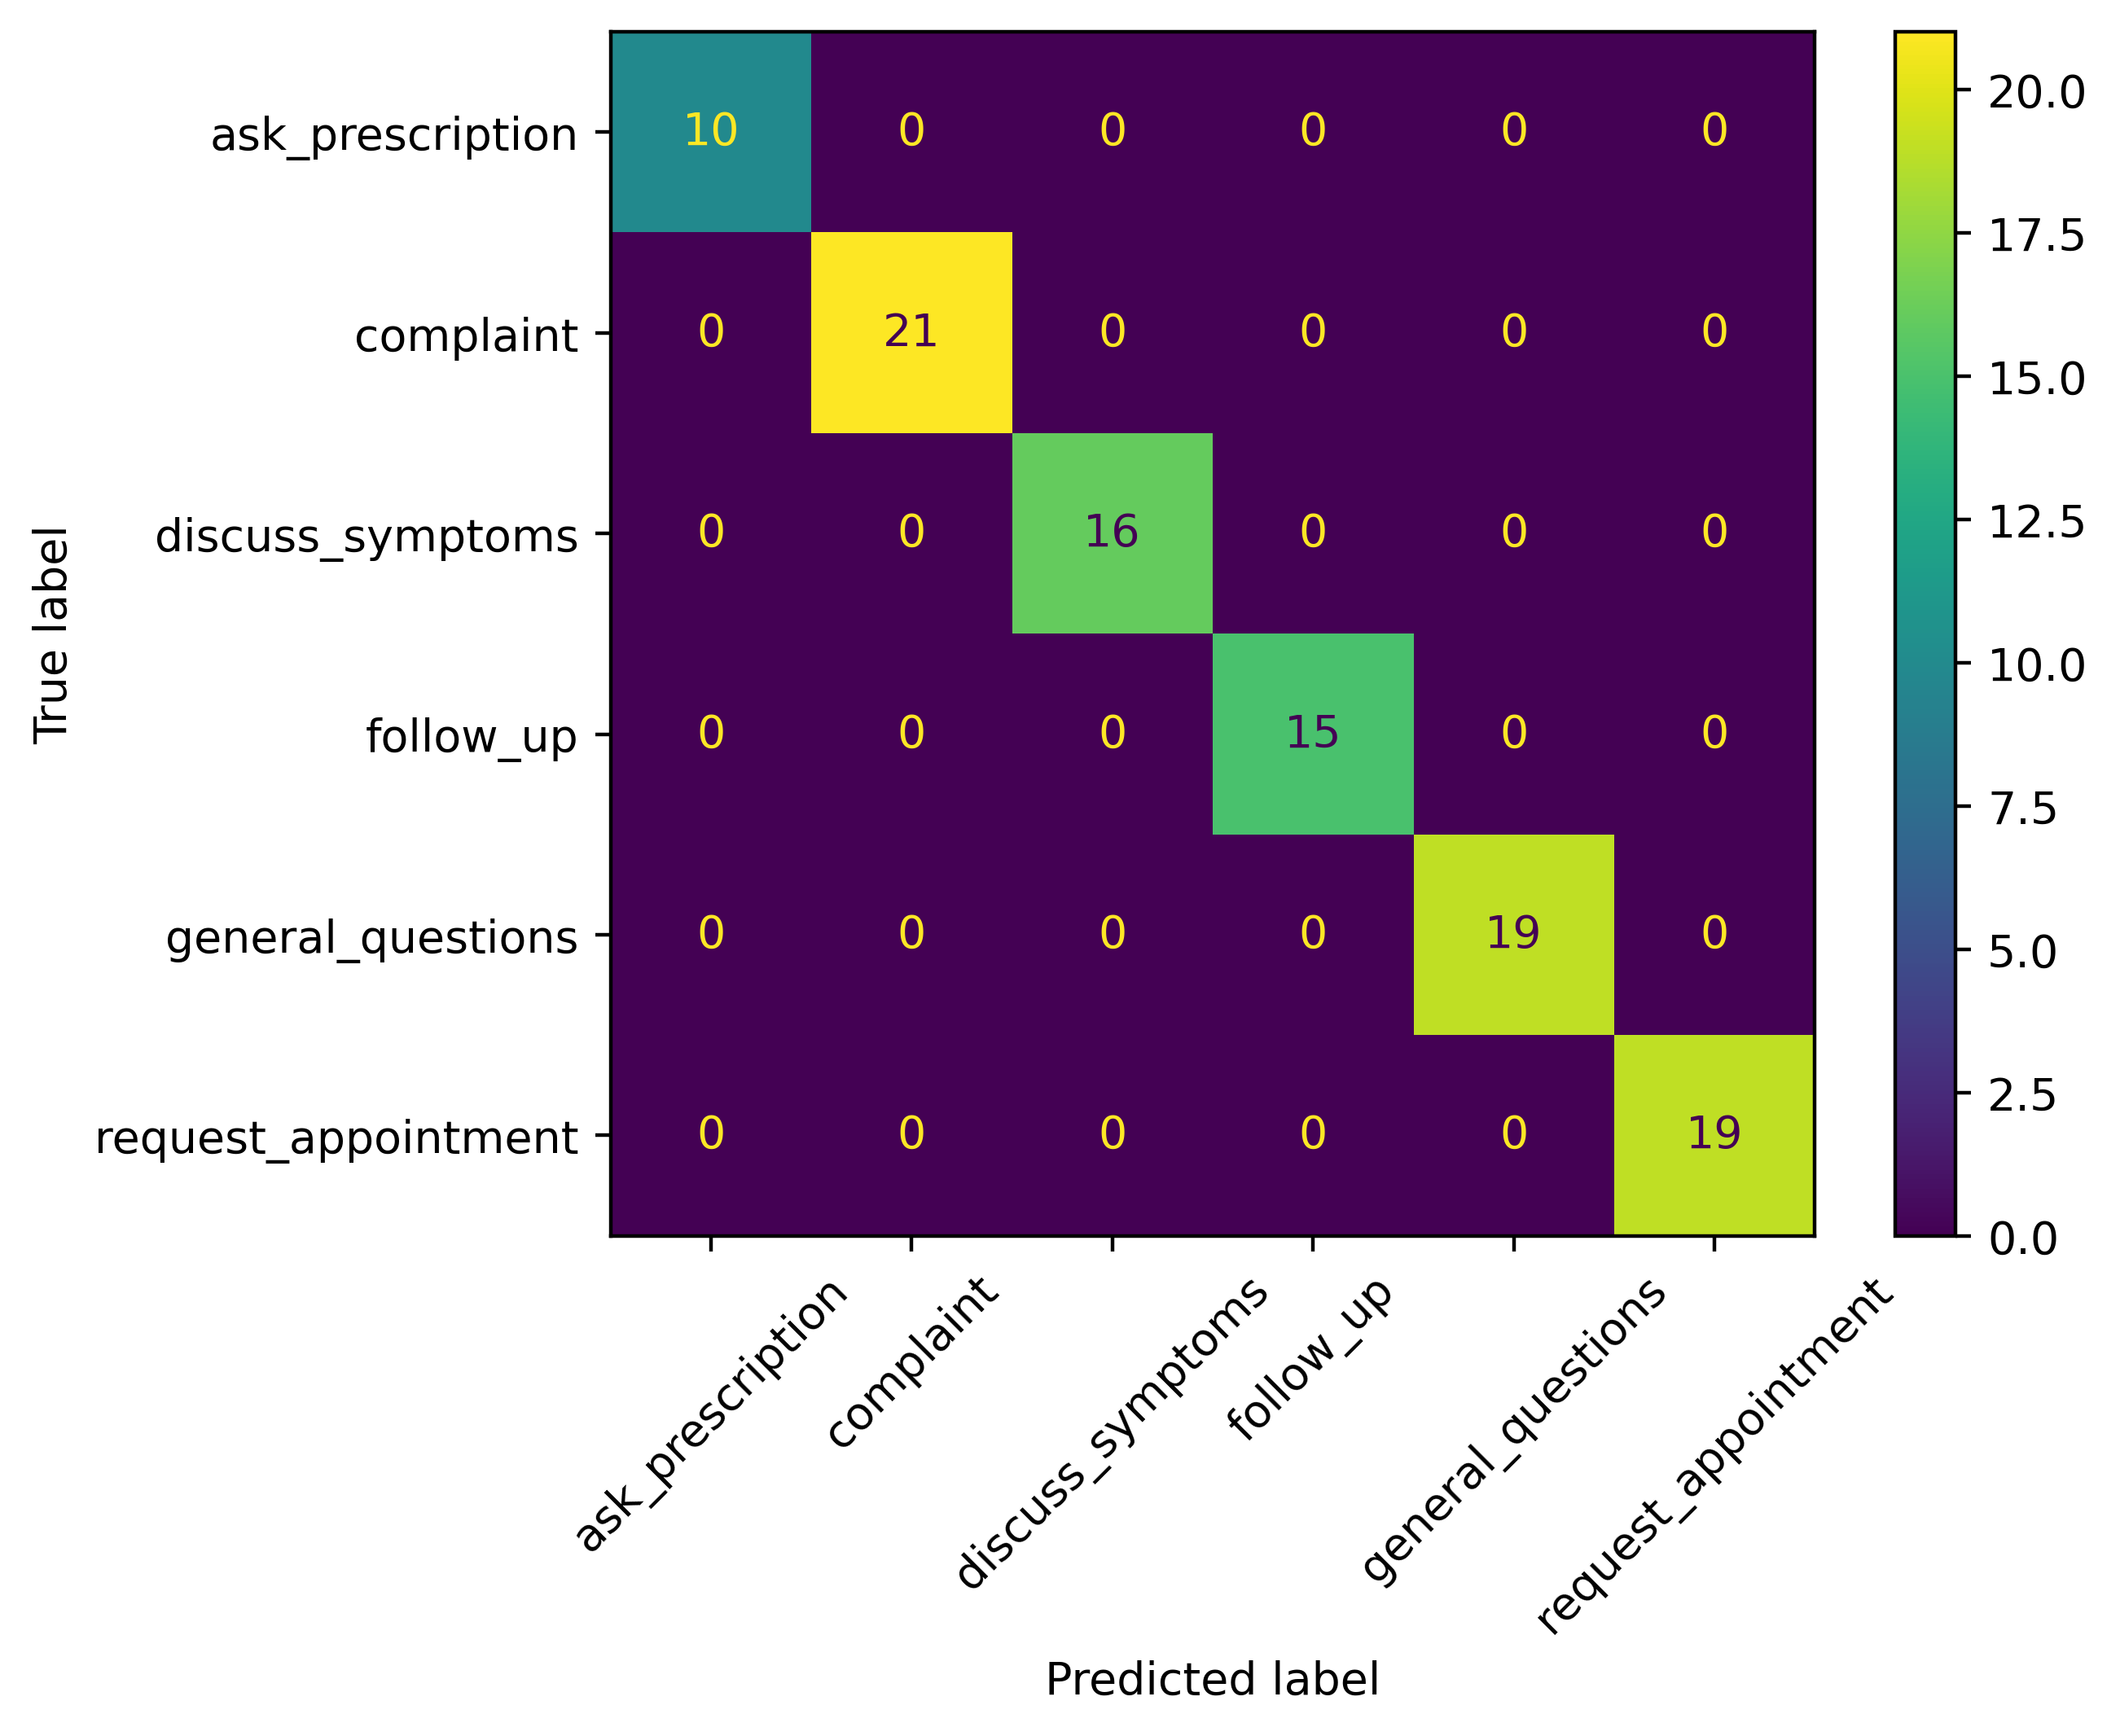

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=le.classes_, xticks_rotation=45)


In [32]:
trainer_model.save_model("C:/works/task_agenixai/intent_model")

In [48]:
from pathlib import Path
model_path = Path("C:/works/task_agenixai/intent_model")

In [52]:
from transformers import pipeline

# Load your trained pipeline
classifier = pipeline("text-classification", model=model_path, tokenizer=tokenizer)

# Assuming you used LabelEncoder and it's named 'le'
def predict_intent(text):
    result = classifier(text)[0]
    label_index = int(result['label'].split('_')[-1])  # Get the numeric part from 'LABEL_4'
    class_name = le.inverse_transform([label_index])[0]
    print(f"Predicted Intent: {class_name} (Confidence: {round(result['score'], 2)})")


# Example
predict_intent("Doc thank you for the surgery now i can walk again")

Device set to use cpu


Predicted Intent: follow_up (Confidence: 0.59)
